# Atmospheric Correction of OSOAA Simulated TOA Radiances

This notebook applies the `correct_atmosphere` package to top-of-atmosphere (TOA) radiances generated by the OSOAA radiative transfer model (notebook 06). Since we know the "true" water-leaving reflectance from OSOAA, we can directly evaluate the accuracy of the atmospheric correction.

### Key consideration: gas absorption

OSOAA is a **scattering-only** radiative transfer model. It handles Rayleigh scattering, aerosols, ocean surface, and hydrosols, but does **not** include gas absorption (ozone, NO$_2$, water vapor). We must account for this when running the correction.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from correct_atmosphere.correction import (
    AtmosphericCorrection,
    GeometryAngles,
    AncillaryData,
)

---
## 1. Load the OSOAA Dataset

The dataset was produced in notebook 06 and saved as `osoaa_toa_dataset.json`. It contains:
- **TOA reflectance** ($\pi L_t / F_0$) at 10 MODIS-Aqua wavelengths
- **True water-leaving reflectance** ($\pi L_w / F_0$) from the subsurface simulation
- Viewing geometry and ancillary data used in the simulation

In [3]:
with open(Path("osoaa_toa_dataset.json")) as f:
    data = json.load(f)

wavelengths = np.array(data["wavelengths_nm"])
toa_refl = np.array(data["toa_reflectance"])     # pi*Lt/F0
true_rho_w = np.array(data["true_rho_w"])         # pi*Lw/F0 (subsurface, nadir)
geom = data["geometry"]
anc = data["ancillary"]
scenario = data["scenario"]

print(f"Scenario: {scenario['name']}")
print(f"  Chlorophyll: {scenario['chlorophyll']} mg/m³")
print(f"  AOT (550 nm): {scenario['aot_550']}")
print(f"\nGeometry:")
print(f"  Solar zenith: {geom['solar_zenith']}°")
print(f"  View zenith:  {geom['view_zenith']}°")
print(f"  Relative azimuth: {abs(geom['view_azimuth'] - geom['solar_azimuth'])}°")
print(f"\nWavelengths ({len(wavelengths)} bands): {wavelengths} nm")

Scenario: Open Ocean - Moderate
  Chlorophyll: 0.3 mg/m³
  AOT (550 nm): 0.1

Geometry:
  Solar zenith: 30.0°
  View zenith:  15.0°
  Relative azimuth: 90.0°

Wavelengths (10 bands): [412 443 469 488 531 547 667 678 748 869] nm


In [4]:
# Summary table
print(f"{'Wavelength (nm)':<18} {'TOA Refl':>12} {'True rho_w':>12} {'Atm Fraction':>14}")
print("-" * 58)
for wl, rho_t, rho_w in zip(wavelengths, toa_refl, true_rho_w):
    atm_frac = 100 * (rho_t - rho_w) / rho_t
    print(f"{wl:>8.0f}          {rho_t:>12.6f} {rho_w:>12.6f} {atm_frac:>12.1f} %")

Wavelength (nm)        TOA Refl   True rho_w   Atm Fraction
----------------------------------------------------------
     412              0.141047     0.040930         71.0 %
     443              0.108579     0.027704         74.5 %
     469              0.090556     0.024073         73.4 %
     488              0.079708     0.021156         73.5 %
     531              0.058507     0.010397         82.2 %
     547              0.053021     0.008299         84.3 %
     667              0.029964     0.000654         97.8 %
     678              0.028944     0.000593         98.0 %
     748              0.023966     0.000079         99.7 %
     869              0.019637     0.000037         99.8 %


---
## 2. Examine the Simulation Data

The atmosphere contributes 70-99% of the TOA signal. Recovering the small water-leaving component accurately is the central challenge of atmospheric correction.

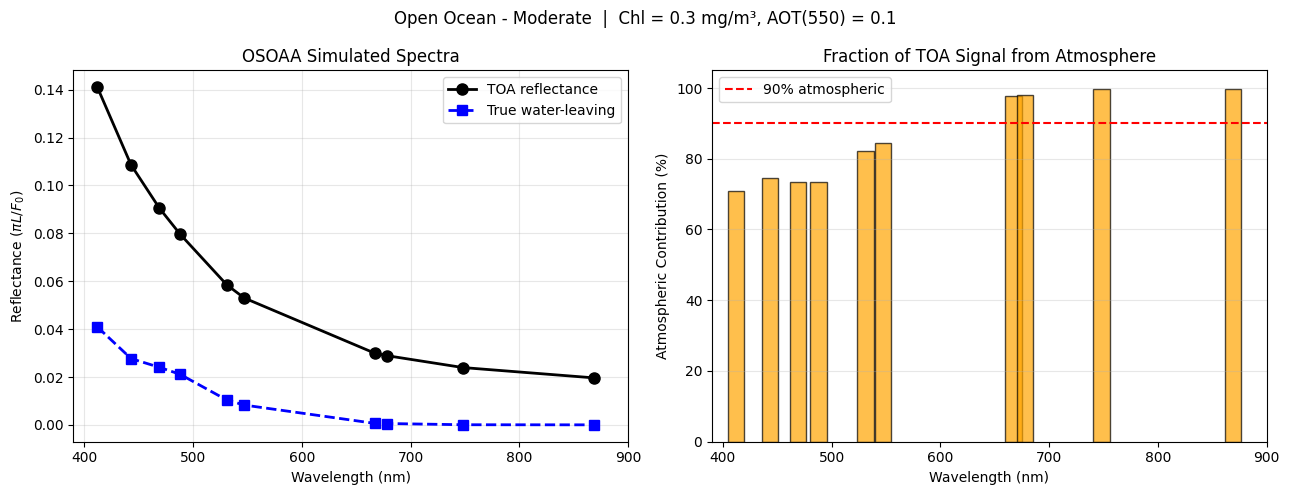

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: spectra
ax = axes[0]
ax.plot(wavelengths, toa_refl, "ko-", ms=8, lw=2, label="TOA reflectance")
ax.plot(wavelengths, true_rho_w, "bs--", ms=7, lw=2, label="True water-leaving")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"Reflectance ($\pi L / F_0$)")
ax.set_title("OSOAA Simulated Spectra")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(390, 900)

# Right: atmospheric fraction
ax = axes[1]
atm_frac = 100 * (toa_refl - true_rho_w) / toa_refl
ax.bar(wavelengths, atm_frac, width=15, color="orange", alpha=0.7, edgecolor="black")
ax.axhline(90, color="red", ls="--", lw=1.5, label="90% atmospheric")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Atmospheric Contribution (%)")
ax.set_title("Fraction of TOA Signal from Atmosphere")
ax.set_ylim(0, 105)
ax.set_xlim(390, 900)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"{scenario['name']}  |  Chl = {scenario['chlorophyll']} mg/m³, "
             f"AOT(550) = {scenario['aot_550']}", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Set Up the Atmospheric Correction

We need to:
1. Create the `AtmosphericCorrection` processor for MODIS-Aqua
2. Convert the OSOAA normalized reflectance ($\pi L_t / F_0$) back to radiance ($L_t$ in mW cm$^{-2}$ $\mu$m$^{-1}$ sr$^{-1}$), since `ac.process()` expects radiance
3. Create geometry and ancillary objects

Since OSOAA does not model gas absorption, we set ozone and NO$_2$ to zero so the correction does not remove a gas signal that was never present.

In [6]:
# Create the processor
ac = AtmosphericCorrection("modis_aqua")

# Get the solar irradiance F0 used internally
F0 = ac._get_solar_irradiance()

# Convert OSOAA reflectance to radiance: pi*Lt/F0 = rho  =>  Lt = rho * F0 / pi
Lt = toa_refl * F0 / np.pi

print("TOA radiance (mW/cm²/µm/sr):")
for wl, lt in zip(wavelengths, Lt):
    print(f"  {wl:.0f} nm: {lt:.4f}")

TOA radiance (mW/cm²/µm/sr):
  412 nm: 7.7632
  443 nm: 6.4845
  469 nm: 5.6567
  488 nm: 4.9458
  531 nm: 3.4592
  547 nm: 3.1482
  667 nm: 1.4522
  678 nm: 1.3640
  748 nm: 0.9770
  869 nm: 0.5957


In [7]:
# Geometry from the OSOAA scenario
geometry = GeometryAngles(
    solar_zenith=geom["solar_zenith"],
    solar_azimuth=geom["solar_azimuth"],
    view_zenith=geom["view_zenith"],
    view_azimuth=geom["view_azimuth"],
)

print(f"Solar zenith:     {geometry.solar_zenith}°")
print(f"View zenith:      {geometry.view_zenith}°")
print(f"Relative azimuth: {geometry.relative_azimuth}°")

Solar zenith:     30.0°
View zenith:      15.0°
Relative azimuth: 90.0°


In [8]:
# Ancillary data — ozone and NO2 set to zero to match OSOAA (no gas absorption)
ancillary_no_gas = AncillaryData(
    pressure=anc["pressure"],
    wind_speed=anc["wind_speed"],
    ozone=0.0,                   # No gas absorption in OSOAA
    water_vapor=0.0,
    relative_humidity=anc["relative_humidity"],
    no2_total=0.0,
    no2_stratospheric=0.0,
)

print("Ancillary data (gas-free):")
print(f"  Pressure:          {ancillary_no_gas.pressure} hPa")
print(f"  Wind speed:        {ancillary_no_gas.wind_speed} m/s")
print(f"  Ozone:             {ancillary_no_gas.ozone} DU (disabled)")
print(f"  Relative humidity: {ancillary_no_gas.relative_humidity}%")

Ancillary data (gas-free):
  Pressure:          1013.25 hPa
  Wind speed:        5.0 m/s
  Ozone:             0.0 DU (disabled)
  Relative humidity: 80.0%


---
## 4. Run the Atmospheric Correction

In [9]:
result = ac.process(Lt, geometry, ancillary_no_gas)

print("Atmospheric correction complete.")
print(f"\nQuality flags:")
print(f"  Glint masked:             {result.flags.glint_masked}")
print(f"  Negative water-leaving:   {result.flags.negative_water_leaving}")
print(f"  Turbid water (non-black): {result.flags.turbid_water}")
print(f"  AC warning:               {result.flags.atmospheric_correction_warning}")
print(f"\nEstimated chlorophyll: {result.chlorophyll:.3f} mg/m³ "
      f"(true: {scenario['chlorophyll']} mg/m³)")

Atmospheric correction complete.

Quality flags:
  Glint masked:             False
  Negative water-leaving:   True
  Turbid water (non-black): False
  AC warning:               True

Estimated chlorophyll: 0.055 mg/m³ (true: 0.3 mg/m³)


---
## 5. Compare Retrieved vs True Water-Leaving Reflectance

The retrieved normalized water-leaving reflectance ($[\rho_w]^{ex}_N$) should ideally match the OSOAA "truth".

**Caveats:**
- OSOAA true $\rho_w$ was extracted at nadir from just below the surface (Level 4), while the correction retrieves above-surface water-leaving reflectance in the viewing direction and normalizes via BRDF.
- The aerosol model in `correct_atmosphere` uses a simple power-law extrapolation, while OSOAA used a physical Mie-scattering maritime aerosol.
- Rayleigh scattering uses a single-scattering approximation as a fallback, while OSOAA uses multiple scattering.

We therefore expect qualitative agreement in spectral shape, but quantitative differences in magnitude.

In [10]:
# The retrieved water-leaving reflectance
retrieved_rho_w = result.rho_w

print(f"{'Band (nm)':<12} {'True rho_w':>12} {'Retrieved rho_w':>16} {'Diff':>10} {'Rel Err (%)':>12}")
print("-" * 65)
for i, wl in enumerate(wavelengths):
    diff = retrieved_rho_w[i] - true_rho_w[i]
    rel_err = 100 * diff / true_rho_w[i] if true_rho_w[i] > 1e-6 else np.nan
    print(f"{wl:>8.0f}     {true_rho_w[i]:>12.6f} {retrieved_rho_w[i]:>16.6f} "
          f"{diff:>10.6f} {rel_err:>11.1f}%")

Band (nm)      True rho_w  Retrieved rho_w       Diff  Rel Err (%)
-----------------------------------------------------------------
     412         0.040930         0.023626  -0.017303       -42.3%
     443         0.027704         0.015739  -0.011965       -43.2%
     469         0.024073         0.013420  -0.010653       -44.3%
     488         0.021156         0.011407  -0.009750       -46.1%
     531         0.010397         0.004007  -0.006390       -61.5%
     547         0.008299         0.002599  -0.005700       -68.7%
     667         0.000654        -0.001773  -0.002427      -371.2%
     678         0.000593        -0.001703  -0.002297      -387.1%
     748         0.000079        -0.001246  -0.001325     -1678.7%
     869         0.000037         0.000000  -0.000037      -100.0%


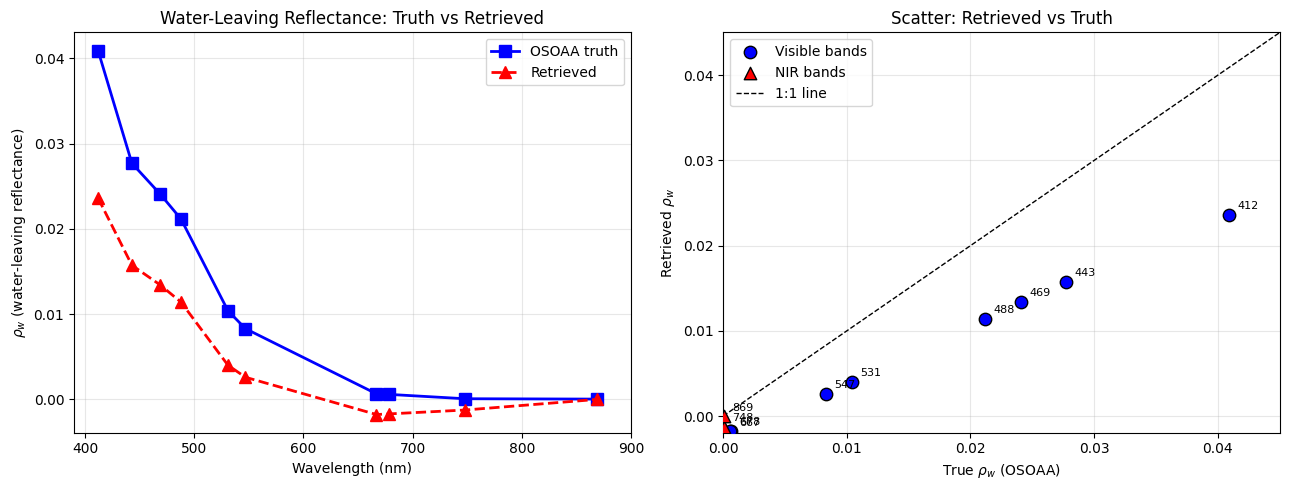

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: spectral comparison
ax = axes[0]
ax.plot(wavelengths, true_rho_w, "bs-", ms=8, lw=2, label="OSOAA truth")
ax.plot(wavelengths, retrieved_rho_w, "r^--", ms=8, lw=2, label="Retrieved")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"$\rho_w$ (water-leaving reflectance)")
ax.set_title("Water-Leaving Reflectance: Truth vs Retrieved")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(390, 900)

# Right: scatter plot
ax = axes[1]
vis = wavelengths < 700
nir = wavelengths >= 700
ax.scatter(true_rho_w[vis], retrieved_rho_w[vis], c="blue", s=80,
           edgecolors="black", zorder=3, label="Visible bands")
ax.scatter(true_rho_w[nir], retrieved_rho_w[nir], c="red", s=80,
           marker="^", edgecolors="black", zorder=3, label="NIR bands")

# Add wavelength labels
for i, wl in enumerate(wavelengths):
    ax.annotate(f"{wl:.0f}", (true_rho_w[i], retrieved_rho_w[i]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# 1:1 line
lims = [0, max(true_rho_w.max(), retrieved_rho_w.max()) * 1.1]
ax.plot(lims, lims, "k--", lw=1, label="1:1 line")
ax.set_xlabel(r"True $\rho_w$ (OSOAA)")
ax.set_ylabel(r"Retrieved $\rho_w$")
ax.set_title("Scatter: Retrieved vs Truth")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(lims)
ax.set_ylim([min(0, retrieved_rho_w.min() * 1.1), lims[1]])

plt.tight_layout()
plt.show()

---
## 6. Error Analysis

Quantify the correction accuracy for visible bands (where ocean color science operates).

Error Statistics (visible bands only):
  Mean absolute error:  0.008311
  RMSE:                 0.009589
  Mean relative error:  -133.0%
  Max absolute error:   0.017303 (at 412 nm)


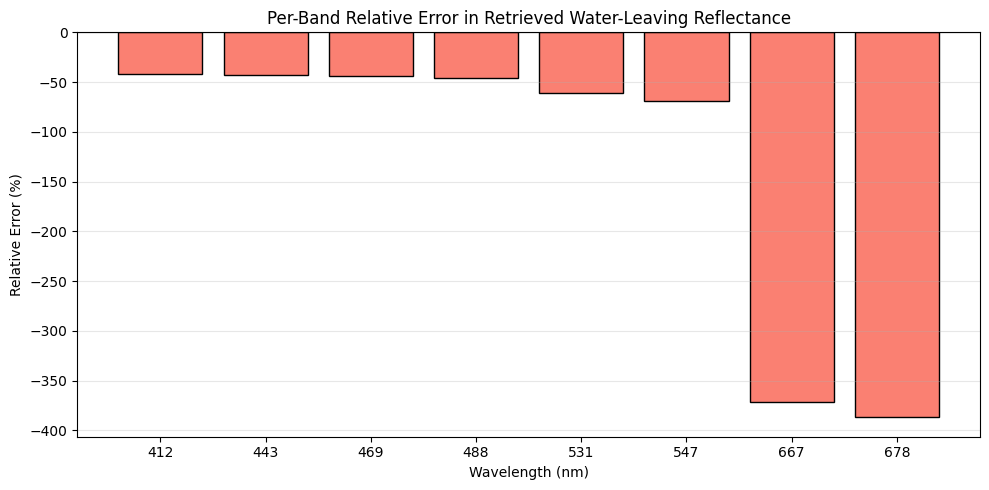

In [12]:
# Focus on visible bands (< 700 nm) where rho_w is significant
vis_mask = wavelengths < 700
vis_wl = wavelengths[vis_mask]
vis_true = true_rho_w[vis_mask]
vis_retrieved = retrieved_rho_w[vis_mask]

diff = vis_retrieved - vis_true
abs_diff = np.abs(diff)
rel_err = 100 * diff / vis_true

print("Error Statistics (visible bands only):")
print(f"  Mean absolute error:  {abs_diff.mean():.6f}")
print(f"  RMSE:                 {np.sqrt(np.mean(diff**2)):.6f}")
print(f"  Mean relative error:  {rel_err.mean():.1f}%")
print(f"  Max absolute error:   {abs_diff.max():.6f} (at {vis_wl[abs_diff.argmax()]:.0f} nm)")

# Bar chart of per-band relative error
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if e > 0 else "salmon" for e in rel_err]
ax.bar([str(int(w)) for w in vis_wl], rel_err, color=colors, edgecolor="black")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Per-Band Relative Error in Retrieved Water-Leaving Reflectance")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 7. Correction Breakdown

Let's examine the individual atmospheric components that were removed during correction.

In [13]:
# Retrieve internal components by re-running key steps
cos_sza = np.cos(np.deg2rad(geom["solar_zenith"]))

# TOA reflectance as used internally: rho_t = pi * Lt / (F0 * cos_sza)
rho_t = toa_refl / cos_sza

# Rayleigh reflectance
rho_r = ac._compute_rayleigh_reflectance(geometry, ancillary_no_gas)

# Whitecap reflectance
rho_wc = ac._compute_whitecap_reflectance(ancillary_no_gas.wind_speed)

# Diffuse transmittance
t_dv = ac._compute_diffuse_transmittance(geometry, ancillary_no_gas)

# Glint reflectance
_vec_glint_refl = np.vectorize(__import__("correct_atmosphere.glint", fromlist=["sun_glint_reflectance"]).sun_glint_reflectance)
rho_g = np.zeros(len(wavelengths))
for i, wl in enumerate(wavelengths):
    rho_g[i] = _vec_glint_refl(
        geometry.solar_zenith, geometry.view_zenith,
        geometry.relative_azimuth, ancillary_no_gas.wind_speed, wl,
    )

# Aerosol reflectance (from result)
rho_A = result.La * np.pi / (F0 * cos_sza)

print(f"{'Band (nm)':<10} {'rho_t':>8} {'rho_r':>8} {'rho_g':>8} {'rho_wc':>8} {'rho_A':>8} {'rho_w':>8}")
print("-" * 62)
for i, wl in enumerate(wavelengths):
    print(f"{wl:>6.0f}     {rho_t[i]:>8.4f} {rho_r[i]:>8.4f} {rho_g[i]:>8.4f} "
          f"{rho_wc[i]:>8.5f} {rho_A[i]:>8.4f} {retrieved_rho_w[i]:>8.4f}")

Band (nm)     rho_t    rho_r    rho_g   rho_wc    rho_A    rho_w
--------------------------------------------------------------
   412       0.1629   0.1203   0.0037  0.00000   0.0206   0.0236
   443       0.1254   0.0891   0.0044  0.00000   0.0192   0.0157
   469       0.1046   0.0704   0.0049  0.00000   0.0181   0.0134
   488       0.0920   0.0598   0.0052  0.00000   0.0174   0.0114
   531       0.0676   0.0423   0.0058  0.00000   0.0160   0.0040
   547       0.0612   0.0375   0.0059  0.00000   0.0156   0.0026
   667       0.0346   0.0167   0.0067  0.00000   0.0128  -0.0018
   678       0.0334   0.0157   0.0067  0.00000   0.0125  -0.0017
   748       0.0277   0.0105   0.0069  0.00000   0.0114  -0.0012
   869       0.0227   0.0057   0.0071  0.00000   0.0098   0.0000


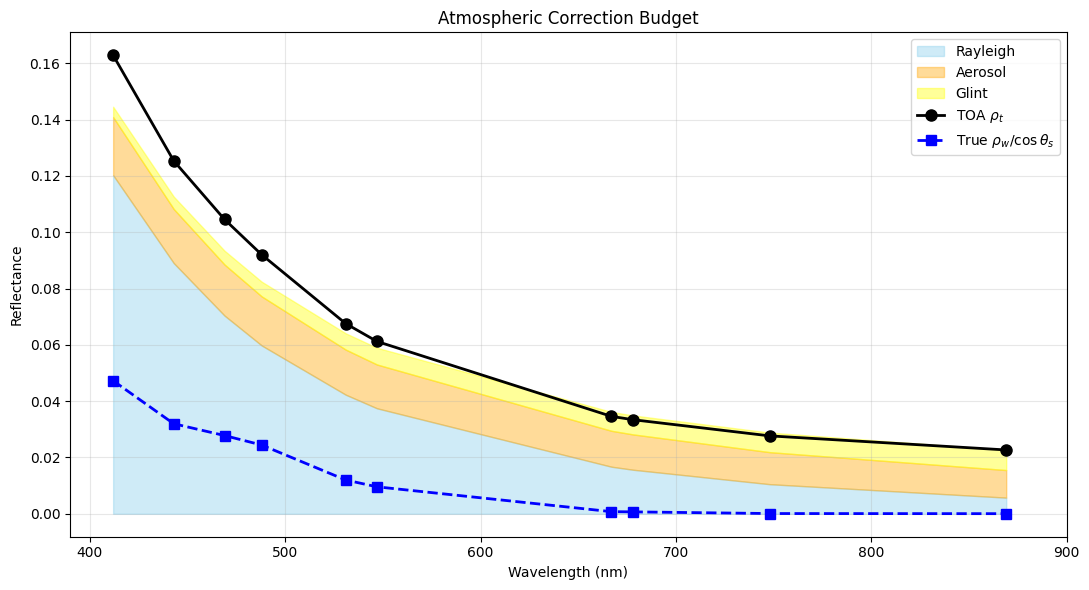

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(wavelengths, 0, rho_r, alpha=0.4, label="Rayleigh", color="skyblue")
ax.fill_between(wavelengths, rho_r, rho_r + np.abs(rho_A), alpha=0.4,
                label="Aerosol", color="orange")
ax.fill_between(wavelengths, rho_r + np.abs(rho_A),
                rho_r + np.abs(rho_A) + rho_g, alpha=0.4,
                label="Glint", color="yellow")

ax.plot(wavelengths, rho_t, "ko-", ms=8, lw=2, label=r"TOA $\rho_t$")
ax.plot(wavelengths, true_rho_w / cos_sza, "bs--", ms=7, lw=2,
        label=r"True $\rho_w / \cos\theta_s$")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title("Atmospheric Correction Budget")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(390, 900)
plt.tight_layout()
plt.show()

---
## 8. Impact of Gas Absorption Assumptions

What happens if we apply gas absorption correction to OSOAA data that doesn't include it? This over-corrects the TOA signal and demonstrates why consistent assumptions matter.

In [15]:
# Run with gas correction enabled (ozone = 300 DU, as in the scenario)
ancillary_with_gas = AncillaryData(
    pressure=anc["pressure"],
    wind_speed=anc["wind_speed"],
    ozone=anc["ozone"],
    water_vapor=anc["water_vapor"],
    relative_humidity=anc["relative_humidity"],
)

result_with_gas = ac.process(Lt, geometry, ancillary_with_gas)

print(f"{'Band (nm)':<12} {'True':>10} {'No gas corr':>12} {'With gas corr':>14}")
print("-" * 52)
for i, wl in enumerate(wavelengths):
    print(f"{wl:>8.0f}     {true_rho_w[i]:>10.6f} "
          f"{result.rho_w[i]:>12.6f} {result_with_gas.rho_w[i]:>14.6f}")

Band (nm)          True  No gas corr  With gas corr
----------------------------------------------------
     412       0.040930     0.023626       0.023903
     443       0.027704     0.015739       0.015938
     469       0.024073     0.013420       0.013567
     488       0.021156     0.011407       0.011525
     531       0.010397     0.004007       0.004130
     547       0.008299     0.002599       0.002732
     667       0.000654    -0.001773      -0.001739
     678       0.000593    -0.001703      -0.001673
     748       0.000079    -0.001246      -0.001238
     869       0.000037     0.000000       0.000000


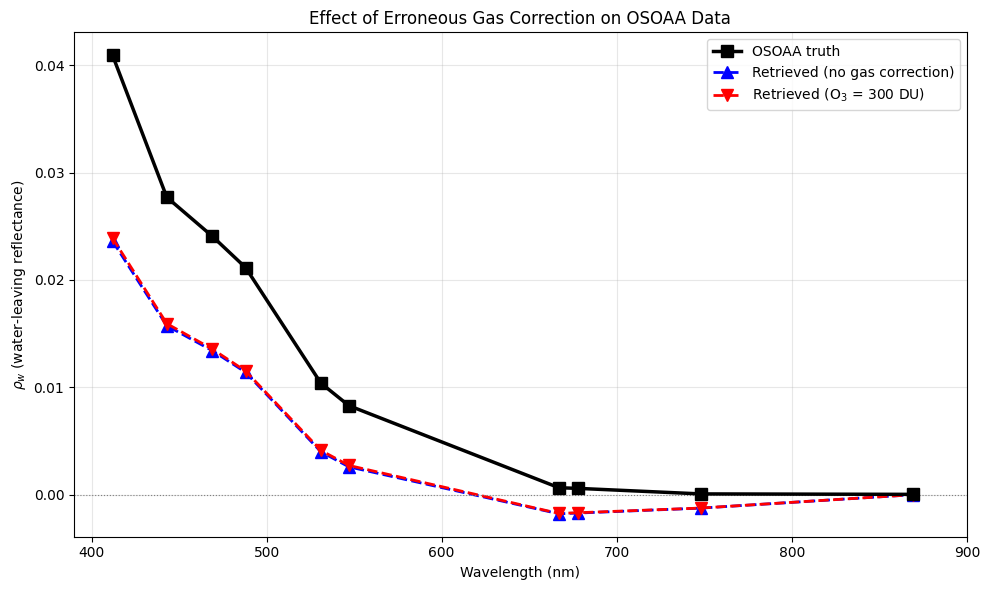

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(wavelengths, true_rho_w, "ks-", ms=9, lw=2.5, label="OSOAA truth", zorder=3)
ax.plot(wavelengths, result.rho_w, "b^--", ms=8, lw=2,
        label="Retrieved (no gas correction)")
ax.plot(wavelengths, result_with_gas.rho_w, "rv--", ms=8, lw=2,
        label=f"Retrieved (O$_3$ = {anc['ozone']:.0f} DU)")

ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"$\rho_w$ (water-leaving reflectance)")
ax.set_title("Effect of Erroneous Gas Correction on OSOAA Data")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(390, 900)
plt.tight_layout()
plt.show()

---
## 9. Rrs and Chlorophyll Comparison

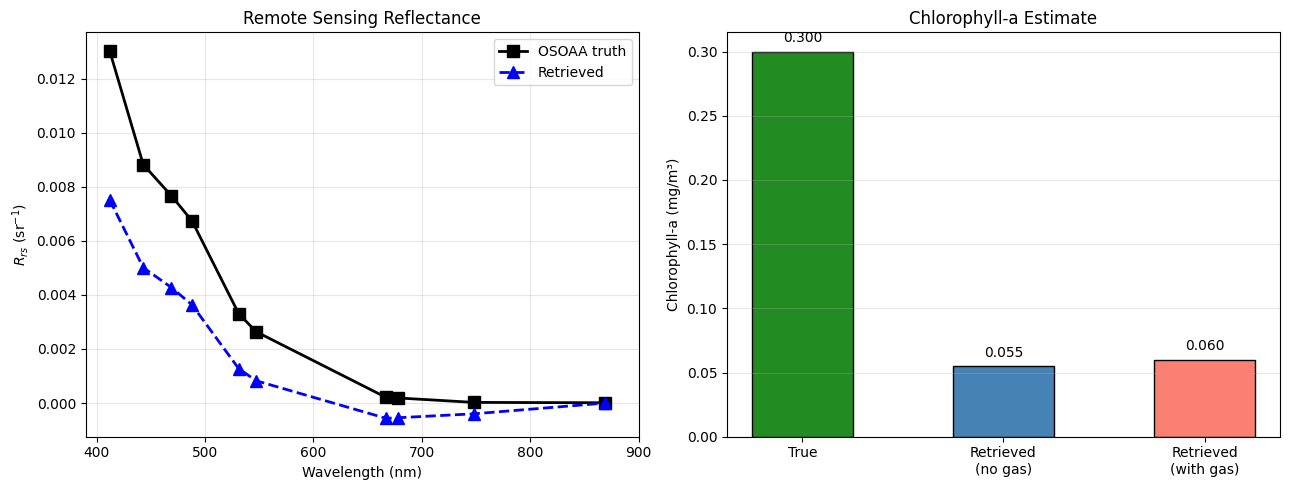

In [17]:
# Convert true rho_w to Rrs for comparison
true_rrs = true_rho_w / np.pi

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rrs comparison
ax = axes[0]
ax.plot(wavelengths, true_rrs, "ks-", ms=8, lw=2, label="OSOAA truth")
ax.plot(wavelengths, result.rrs, "b^--", ms=8, lw=2, label="Retrieved")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"$R_{rs}$ (sr$^{-1}$)")
ax.set_title("Remote Sensing Reflectance")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(390, 900)

# Chlorophyll
ax = axes[1]
labels = ["True", "Retrieved\n(no gas)", "Retrieved\n(with gas)"]
values = [scenario["chlorophyll"], result.chlorophyll, result_with_gas.chlorophyll]
colors = ["forestgreen", "steelblue", "salmon"]
bars = ax.bar(labels, values, color=colors, edgecolor="black", width=0.5)
ax.set_ylabel("Chlorophyll-a (mg/m³)")
ax.set_title("Chlorophyll-a Estimate")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated atmospheric correction of OSOAA-simulated TOA radiances using the `correct_atmosphere` package.

### Key findings

1. **Spectral shape recovery**: The atmospheric correction recovers the general shape of the water-leaving reflectance spectrum, with higher values in the blue and decreasing into the red/NIR.

2. **Gas absorption matters**: Applying gas correction to OSOAA data (which does not include gases) over-corrects the signal, demonstrating the importance of consistent radiative transfer assumptions.

3. **Sources of error**: Differences between retrieved and true $\rho_w$ arise from:
   - Single-scattering Rayleigh approximation vs OSOAA's multiple scattering
   - Simplified aerosol model (power-law extrapolation) vs physical Mie scattering
   - BRDF and geometry normalization differences
   - The OSOAA "truth" is subsurface at nadir, while retrieval is above-surface in the viewing direction

### Next steps

- Run additional OSOAA scenarios (varying AOT, chlorophyll, geometry) and evaluate correction stability
- Replace LUT fallbacks with full implementations for more accurate Rayleigh and aerosol corrections
- Incorporate gas absorption into the OSOAA simulation chain for end-to-end validation